#STEP 1 — INSTALL LIBRARIES

In [1]:
!pip install nltk gensim transformers datasets accelerate evaluate -q

#STEP 2 — IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from gensim.models import Word2Vec
from sklearn.ensemble import RandomForestClassifier

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Embedding, LSTM, Input, MultiHeadAttention, GlobalAveragePooling1D, LayerNormalization, Dropout

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#STEP 3 — LOAD DATASET

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df = pd.read_csv('/content/drive/MyDrive/Suicide_Detection 4.csv')

df.head()

,Unnamed: 0,text,class
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,3,Am I weird I don't get affected by compliments...,non-suicide
2,4,Finally 2020 is almost over... So I can never ...,non-suicide
3,8,i need helpjust help me im crying so hard,suicide
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide



#STEP 4 — DATASET ANALYSIS





In [5]:
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())
print(df['class'].value_counts())

(232074, 3)
Index(['Unnamed: 0', 'text', 'class'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232074 entries, 0 to 232073
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  232074 non-null  int64 
 1   text        232074 non-null  object
 2   class       232074 non-null  object
dtypes: int64(1), object(2)
memory usage: 5.3+ MB
None
Unnamed: 0    0
text          0
class         0
dtype: int64
class
suicide        116037
non-suicide    116037
Name: count, dtype: int64


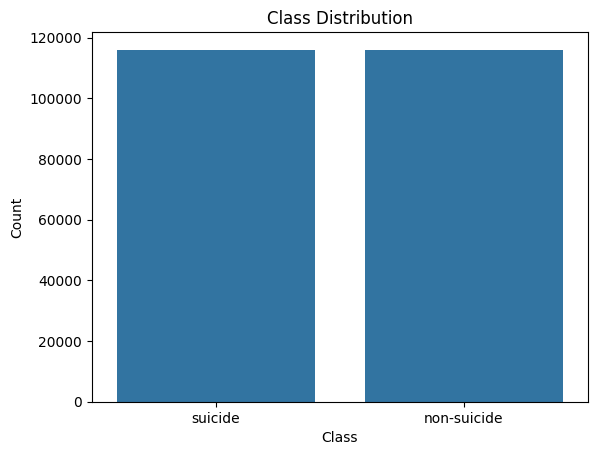

In [6]:
sns.countplot(x=df['class'])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

#STEP 5 — DATA PREPROCESSING

In [7]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(clean_text)

df.head()

,Unnamed: 0,text,class,clean_text
0,2,Ex Wife Threatening SuicideRecently I left my ...,suicide,ex wife threatening suiciderecently left wife ...
1,3,Am I weird I don't get affected by compliments...,non-suicide,weird dont get affected compliments coming som...
2,4,Finally 2020 is almost over... So I can never ...,non-suicide,finally almost never hear bad year ever swear ...
3,8,i need helpjust help me im crying so hard,suicide,need helpjust help im crying hard
4,9,"I’m so lostHello, my name is Adam (16) and I’v...",suicide,’ losthello name adam ’ struggling years ’ afr...


#STEP 6 — ENCODE LABELS

In [9]:
label_mapping = {
    'non-suicide': 0,
    'suicide': 1
}

df['label'] = df['class'].map(label_mapping)

df[['text', 'clean_text', 'class', 'label']].head()

,text,clean_text,class,label
0,Ex Wife Threatening SuicideRecently I left my ...,ex wife threatening suiciderecently left wife ...,suicide,1
1,Am I weird I don't get affected by compliments...,weird dont get affected compliments coming som...,non-suicide,0
2,Finally 2020 is almost over... So I can never ...,finally almost never hear bad year ever swear ...,non-suicide,0
3,i need helpjust help me im crying so hard,need helpjust help im crying hard,suicide,1
4,"I’m so lostHello, my name is Adam (16) and I’v...",’ losthello name adam ’ struggling years ’ afr...,suicide,1


#STEP 7 — TRAIN TEST SPLIT

In [10]:
X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

PART 3 — TF-IDF + LOGISTIC REGRESSION

In [11]:
tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [12]:
# LOGISTIC REGRESSION MODEL

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("TF-IDF Logistic Regression Accuracy:", lr_accuracy)
print(classification_report(y_test, lr_pred))

TF-IDF Logistic Regression Accuracy: 0.9352579984918669
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     23287
           1       0.94      0.93      0.93     23128

    accuracy                           0.94     46415
   macro avg       0.94      0.94      0.94     46415
weighted avg       0.94      0.94      0.94     46415



In [13]:
# TEST TF-IDF MODEL

sample_text = ["I feel hopeless"]

sample_clean = [clean_text(text) for text in sample_text]

sample_vector = tfidf.transform(sample_clean)

prediction = lr_model.predict(sample_vector)

if prediction[0] == 1:
    print("Suicidal Thought Detected")
else:
    print("Non-Suicidal Text")

Suicidal Thought Detected


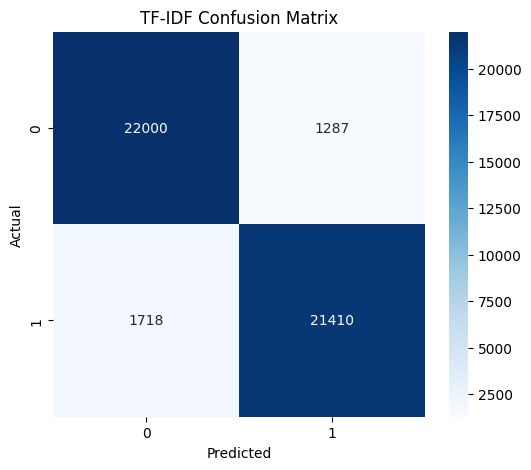

In [14]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap( cm,annot=True,fmt='d',cmap='Blues')

plt.title("TF-IDF Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

#PART 4 — WORD2VEC MODEL

In [15]:
# WORD2VEC TOKENIZATION
tokenized_sentences = [sentence.split() for sentence in X_train]

In [16]:
# TRAIN WORD2VEC EMBEDDINGS
word2vec_model = Word2Vec(
    sentences=tokenized_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [17]:
# CONVERT SENTENCES TO VECTORS
def sentence_vector(sentence):
    words = sentence.split()
    vectors = []

    for word in words:
        if word in word2vec_model.wv:
            vectors.append(word2vec_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_train_w2v = np.array([sentence_vector(sentence) for sentence in X_train])
X_test_w2v = np.array([sentence_vector(sentence) for sentence in X_test])

In [18]:
# TRAIN CLASSIFIER USING WORD2VE
w2v_classifier = RandomForestClassifier(
    n_estimators=50,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

w2v_classifier.fit(X_train_w2v, y_train)

w2v_pred = w2v_classifier.predict(X_test_w2v)

w2v_accuracy = accuracy_score(y_test, w2v_pred)

print("Word2Vec Accuracy:", w2v_accuracy)

print(classification_report(y_test, w2v_pred))

Word2Vec Accuracy: 0.9136916944953141
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     23287
           1       0.91      0.92      0.91     23128

    accuracy                           0.91     46415
   macro avg       0.91      0.91      0.91     46415
weighted avg       0.91      0.91      0.91     46415



In [19]:
# TEST WORD2VEC MODEL

test_sentence = "I want to end my life"

clean_sentence = clean_text(test_sentence)

vector = sentence_vector(clean_sentence)

vector = vector.reshape(1, -1)

prediction = w2v_classifier.predict(vector)

if prediction[0] == 1:
    print("Suicidal Thought Detected")
else:
    print("Non-Suicidal Text")

Suicidal Thought Detected


In [20]:
# WORD2VEC EVALUATION
print("Word2Vec Accuracy:",
      accuracy_score(y_test, w2v_pred))

print(classification_report(y_test, w2v_pred))

Word2Vec Accuracy: 0.9136916944953141
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     23287
           1       0.91      0.92      0.91     23128

    accuracy                           0.91     46415
   macro avg       0.91      0.91      0.91     46415
weighted avg       0.91      0.91      0.91     46415



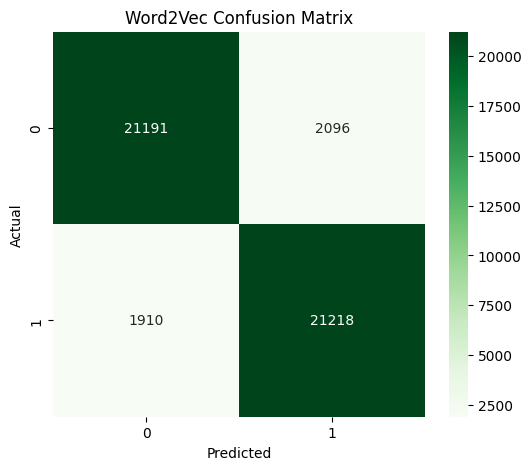

In [21]:
cm = confusion_matrix(y_test, w2v_pred)
plt.figure(figsize=(6,5))
sns.heatmap( cm,annot=True,fmt='d', cmap='Greens')

plt.title("Word2Vec Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

i had to reduce because suicide dataset is huge (around 230k+ rows), and RandomForestClassifier is slow with:

* many samples
* 100-dimensional Word2Vec vectors
* default number of trees
 it was loading forever

#PART 5 — LSTM MODEL

In [22]:
# TOKENIZATION
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

In [23]:
# PADDING
max_length = 100

X_train_pad = pad_sequences(train_sequences, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(test_sequences, maxlen=max_length, padding='post')

In [25]:
history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 61s 10ms/step - accuracy: 0.9126 - loss: 0.2137 - val_accuracy: 0.9512 - val_loss: 0.1282
Epoch 2/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - accuracy: 0.9587 - loss: 0.1130 - val_accuracy: 0.9488 - val_loss: 0.1309
Epoch 3/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 54s 9ms/step - accuracy: 0.9662 - loss: 0.0926 - val_accuracy: 0.9507 - val_loss: 0.1338
Epoch 4/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 60s 10ms/step - accuracy: 0.9730 - loss: 0.0746 - val_accuracy: 0.9498 - val_loss: 0.1449
Epoch 5/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 56s 10ms/step - accuracy: 0.9792 - loss: 0.0574 - val_accuracy: 0.9462 - val_loss: 0.1562


In [24]:
# BUILD LSTM MODE
lstm_model = Sequential()

lstm_model.add(Embedding(input_dim=10000, output_dim=64, input_length=max_length))
lstm_model.add(LSTM(64))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
# TEST LSTM MODEL
sample_text = ["I feel depressed"]
sequence = tokenizer.texts_to_sequences(sample_text)
padded = pad_sequences(sequence, maxlen=max_length, padding='post')
prediction = lstm_model.predict(padded)
if prediction[0][0] > 0.5:
    print("Suicidal Thought Detected")
else:
    print("Non-Suicidal Text")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Suicidal Thought Detected


In [27]:
# LSTM EVALUATION
lstm_pred = lstm_model.predict(X_test_pad)

lstm_pred = (lstm_pred > 0.5).astype(int)

print("LSTM Accuracy:",
      accuracy_score(y_test, lstm_pred))

print(classification_report(y_test, lstm_pred))

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
LSTM Accuracy: 0.9462027361844232
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     23287
           1       0.95      0.94      0.95     23128

    accuracy                           0.95     46415
   macro avg       0.95      0.95      0.95     46415
weighted avg       0.95      0.95      0.95     46415



1451/1451 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


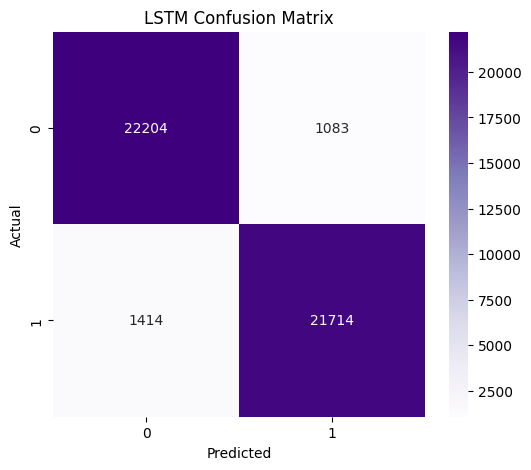

In [28]:
lstm_pred = lstm_model.predict(X_test_pad)
lstm_pred = (lstm_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, lstm_pred)
plt.figure(figsize=(6,5))

sns.heatmap(cm,annot=True,fmt='d', cmap='Purples')
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [29]:
# EVALUATE LSTM MODEL

loss, lstm_accuracy = lstm_model.evaluate(X_test_pad, y_test)

print("LSTM Accuracy:", lstm_accuracy)

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9462 - loss: 0.1562
LSTM Accuracy: 0.9462027549743652


#PART 6 — TRANSFORMER / ATTENTION MODEL

In [30]:
# TRANSFORMER BLOCK

def transformer_block(inputs):
    attention = MultiHeadAttention(num_heads=4, key_dim=64)(inputs, inputs)
    attention = Dropout(0.1)(attention)

    x = LayerNormalization()(inputs + attention)

    dense = Dense(64, activation='relu')(x)
    dense = Dense(64)(dense)

    output = LayerNormalization()(x + dense)

    return output

In [31]:
# BUILD TRANSFORMER MODEL

input_layer = Input(shape=(max_length,))

embedding = Embedding(input_dim=10000, output_dim=64)(input_layer)

transformer = transformer_block(embedding)

pooling = GlobalAveragePooling1D()(transformer)

dense = Dense(32, activation='relu')(pooling)

output = Dense(1, activation='sigmoid')(dense)

transformer_model = Model(inputs=input_layer, outputs=output)

transformer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transformer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 100, 64)   │    640,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 100, 64)   │     66,368 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 100, 64)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 100, 64)   │          0 │ embedding_1[0][0… │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 100, 64)   │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 100, 64)   │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 100, 64)   │      4,160 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 100, 64)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 100, 64)   │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 717,057 (2.74 MB)

 Trainable params: 717,057 (2.74 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# TRAIN TRANSFORMER MODEL

transformer_history = transformer_model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test)
)

Epoch 1/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 50s 7ms/step - accuracy: 0.9305 - loss: 0.1839 - val_accuracy: 0.9440 - val_loss: 0.1530
Epoch 2/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - accuracy: 0.9513 - loss: 0.1317 - val_accuracy: 0.9455 - val_loss: 0.1463
Epoch 3/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - accuracy: 0.9574 - loss: 0.1142 - val_accuracy: 0.9462 - val_loss: 0.1480
Epoch 4/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - accuracy: 0.9627 - loss: 0.1004 - val_accuracy: 0.9440 - val_loss: 0.1608
Epoch 5/5
5802/5802 ━━━━━━━━━━━━━━━━━━━━ 33s 6ms/step - accuracy: 0.9670 - loss: 0.0876 - val_accuracy: 0.9430 - val_loss: 0.1671


In [33]:
# TRANSFORMER EVALUATION

transformer_pred = transformer_model.predict(X_test_pad)

transformer_pred = (transformer_pred > 0.5).astype(int)

print("Transformer Accuracy:",
      accuracy_score(y_test, transformer_pred))

print(classification_report(y_test, transformer_pred))

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Transformer Accuracy: 0.9430356565765378
              precision    recall  f1-score   support

           0       0.94      0.95      0.94     23287
           1       0.95      0.93      0.94     23128

    accuracy                           0.94     46415
   macro avg       0.94      0.94      0.94     46415
weighted avg       0.94      0.94      0.94     46415



In [34]:
# EVALUATE TRANSFORMER MODEL

loss, transformer_accuracy = transformer_model.evaluate(X_test_pad, y_test)

print("Transformer Accuracy:", transformer_accuracy)

1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9430 - loss: 0.1671
Transformer Accuracy: 0.9430356621742249


In [35]:
# TEST TRANSFORMER MODEL
sample_text = ["I hate my life"]
sequence = tokenizer.texts_to_sequences(sample_text)
padded = pad_sequences(sequence, maxlen=max_length, padding='post')
prediction = transformer_model.predict(padded)
if prediction[0][0] > 0.5:
    print("Suicidal Thought Detected")
else:
    print("Non-Suicidal Text")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 713ms/step
Non-Suicidal Text


1451/1451 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


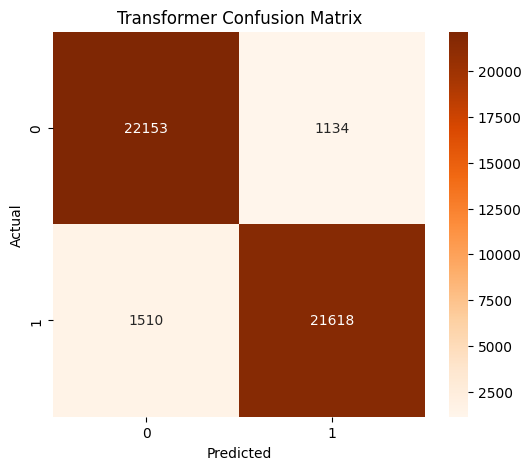

In [36]:
transformer_pred = transformer_model.predict(X_test_pad)
transformer_pred = (transformer_pred > 0.5).astype(int)
cm = confusion_matrix(y_test, transformer_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges')
plt.title("Transformer Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#PART 7 — BERT FINE-TUNING

In [50]:
!pip install numpy==1.26.4 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompa

In [11]:
# IMPORT BERT LIBRARIES
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

In [12]:
# CREATE DATAFRAMES FOR BERT
bert_train_df = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

bert_test_df = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

In [13]:
# CONVERT TO HUGGINGFACE DATASET
train_dataset = Dataset.from_pandas(bert_train_df)
test_dataset = Dataset.from_pandas(bert_test_df)

In [14]:
# LOAD BERT TOKENIZER
bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [15]:
# TOKENIZATION FUNCTION
def tokenize_function(example):
    return bert_tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

In [16]:
# TOKENIZE DATASETS
train_dataset = train_dataset.map(tokenize_function)
test_dataset = test_dataset.map(tokenize_function)

Map:   0%|          | 0/185659 [00:00<?, ? examples/s]

Map:   0%|          | 0/46415 [00:00<?, ? examples/s]

In [17]:
# REMOVE UNUSED COLUMNS
train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])

In [18]:
# SET FORMAT
train_dataset.set_format("torch")
test_dataset.set_format("torch")

In [19]:
# LOAD BERT MODEL
bert_model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
# EVALUATION FUNCTION
def compute_metrics(pred):
    predictions = np.argmax(pred.predictions, axis=1)

    return {
        "accuracy": accuracy_score(pred.label_ids, predictions)
    }

In [21]:
# TRAINING ARGUMENTS
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01
)

In [22]:
# TRAINER
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

i had to uninstall and restart in order to train BERT model

In [26]:
!pip uninstall -y torchvision
!pip install torchvision==0.17.2 -q
!pip install torch==2.2.2 torchaudio==2.2.2 -q
!pip install numpy==1.26.4 --force-reinstall -q

Found existing installation: torchvision 0.17.2
Uninstalling torchvision-0.17.2:
  Successfully uninstalled torchvision-0.17.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 95.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= 

In [23]:
# TRAIN BERT MODEL
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.092361,0.087108,0.976753
2,0.065105,0.099768,0.979511


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=46416, training_loss=0.08975073893454025, metrics={'train_runtime': 6244.2764, 'train_samples_per_second': 59.465, 'train_steps_per_second': 7.433, 'total_flos': 1.221223385677056e+16, 'train_loss': 0.08975073893454025, 'epoch': 2.0})

In [24]:
# EVALUATE BERT MODEL
bert_results = trainer.evaluate()

print(bert_results)

bert_accuracy = bert_results['eval_accuracy']

{'eval_loss': 0.09976792335510254, 'eval_accuracy': 0.979510933965313, 'eval_runtime': 182.0722, 'eval_samples_per_second': 254.926, 'eval_steps_per_second': 31.866, 'epoch': 2.0}


In [25]:
bert_predictions = trainer.predict(test_dataset)

y_pred_bert = bert_predictions.predictions.argmax(axis=1)

In [26]:
print("BERT Accuracy:",
      accuracy_score(y_test, y_pred_bert))

print(classification_report(y_test, y_pred_bert))

BERT Accuracy: 0.979510933965313
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     23287
           1       0.98      0.98      0.98     23128

    accuracy                           0.98     46415
   macro avg       0.98      0.98      0.98     46415
weighted avg       0.98      0.98      0.98     46415



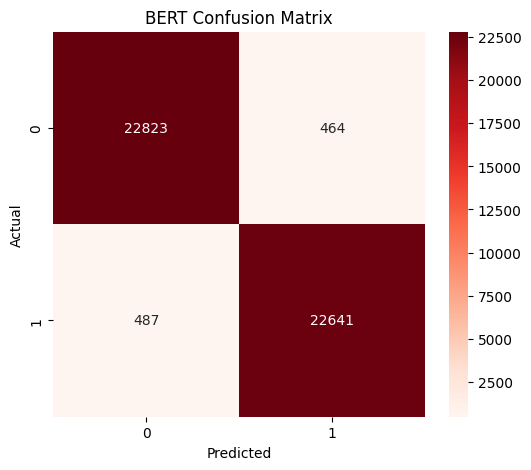

In [27]:
cm = confusion_matrix(y_test, y_pred_bert)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

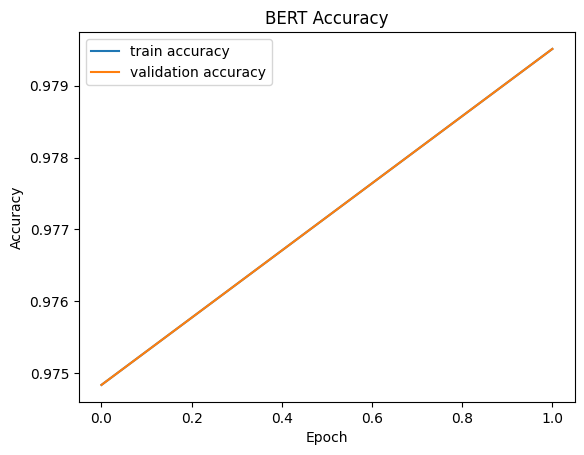

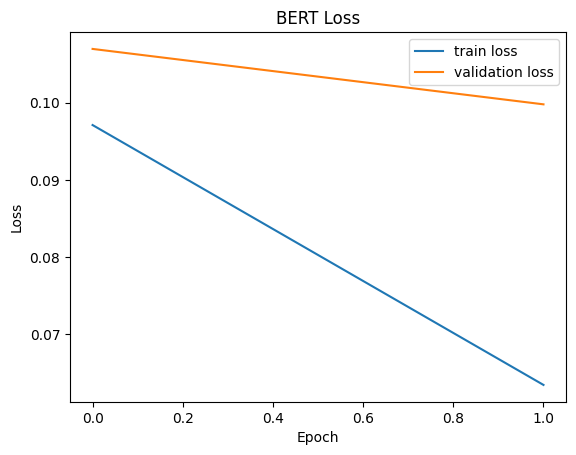

In [35]:
# STEP 12 — VISUALIZE BERT TRAINING
bert_accuracy = [0.974836, 0.979511]
bert_val_accuracy = [0.974836, 0.979511]
bert_loss = [0.097088, 0.063463]
bert_val_loss = [0.106937, 0.099767]
# ACCURACY GRAPH
plt.plot(bert_accuracy, label='train accuracy')
plt.plot(bert_val_accuracy, label='validation accuracy')
plt.legend()
plt.title("BERT Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# LOSS GRAPH
plt.plot(bert_loss, label='train loss')
plt.plot(bert_val_loss, label='validation loss')
plt.legend()
plt.title("BERT Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [31]:
# TEST SINGLE TEXT WITH BERT
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model.to(device)
def predict_bert_text(text):

    inputs = bert_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )
    inputs = {key: value.to(device) for key, value in inputs.items()}
    with torch.no_grad():
        outputs = bert_model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=1).item()
    print("Text:", text)
    if prediction == 1:
        print("Prediction: Suicidal")
    else:
        print("Prediction: Non-Suicidal")

In [34]:
predict_bert_text("I feel happy ")

Text: I feel happy 
Prediction: Non-Suicidal


In [33]:
predict_bert_text("Today was a beautiful day")

Text: Today was a beautiful day
Prediction: Non-Suicidal
